In [1]:
import os
import sys
from datetime import datetime

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns_infinite
import infinite
reload(plotting)
reload(pinns_infinite)
reload(infinite)
import numpy as np
import sympy as sp
from pathlib import Path
from matplotlib.colors import LogNorm, Normalize
import pandas as pd
from calflops import calculate_flops
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns_infinite import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from pinns_infinite import build_models
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Source: results_kan_infinite_optuna_2026-09-20_01-43-35/data/study.csv
Best objective: 1.748967e-03
hidden_layers: 3
hidden_units: 15
grid_size: 5
spline_order: 4
learning_rate: 0.0001


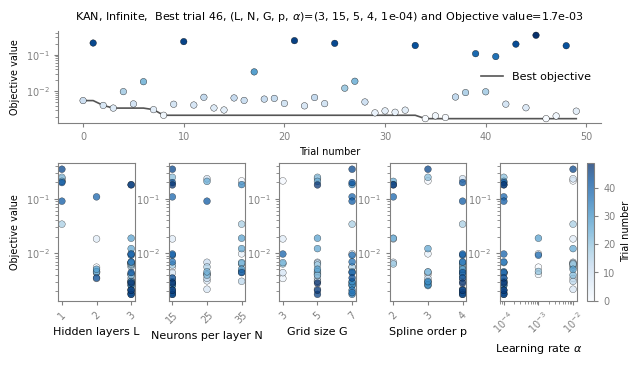

In [2]:
from pathlib import Path
from matplotlib.colors import LogNorm, Normalize
import numpy as np
import pandas as pd

# Select the newest Optuna export that is available.
results_root = Path(".")
study_paths = sorted(results_root.glob("results_kan_infinite_optuna_2026-09-20_01-43-35/data/study.csv"))
summary_paths = sorted(results_root.glob("results_kan_infinite_optuna_2026-09-20_01-43-35/summary_metrics.csv"))

if study_paths:
    source_path = study_paths[-1]
    trials = pd.read_csv(source_path)
    trials = trials[trials["state"].eq("COMPLETE")].copy()
    trials["objective"] = trials["value"]
    parameter_columns = {
        "hidden_layers": "params_hidden_layers",
        "hidden_units": "params_hidden_units",
        "grid_size": "params_grid_size",
        "spline_order": "params_spline_order",
        "learning_rate": "params_learning_rate",
    }
else:
    if not summary_paths:
        raise FileNotFoundError("No study.csv or summary_metrics.csv was found.")
    source_path = summary_paths[-1]
    trials = pd.read_csv(source_path).copy()
    trials = trials.assign(number=np.arange(len(trials)))
    trials["objective"] = trials["mean_global_error"]
    parameter_columns = {
        "hidden_layers": "hidden_layers",
        "hidden_units": "hidden_units",
        "grid_size": "grid_size",
        "spline_order": "spline_order",
        "learning_rate": "adam_lr",
    }

trials = trials.sort_values("number").reset_index(drop=True)
trials = trials[trials["objective"] > 0].copy()
if trials.empty:
    raise ValueError("The selected result file has no positive completed objectives.")

best_trial = trials.loc[trials["objective"].idxmin()]
print(f"Source: {source_path}")
print(f"Best objective: {best_trial['objective']:.6e}")
for name, column in parameter_columns.items():
    print(f"{name}: {best_trial[column]}")

# Build a two-panel figure: history and parameter slices.
axis_color = "#808080"
fig = plt.figure(figsize=(7, 3.5))
grid = fig.add_gridspec(2, 1, height_ratios=(1.2, 1.8), hspace=0.35)

ax_history = fig.add_subplot(grid[0, 0])
best_values = trials["objective"].cummin()
ax_history.plot(trials["number"], best_values, color="#555555", linewidth=1.2, label="Best objective")
ax_history.scatter(trials["number"], trials["objective"], c=trials["objective"], cmap="Blues", norm=LogNorm(trials["objective"].min(), trials["objective"].max()), edgecolors="black", linewidths=0.25, s=22, zorder=2)
best_configuration = (
    f"KAN, Infinite,  Best trial {int(best_trial['number'])}, "
    f"(L, N, G, p, $\\alpha$)=({int(best_trial[parameter_columns['hidden_layers']])},"
    f" {int(best_trial[parameter_columns['hidden_units']])},"
    f" {int(best_trial[parameter_columns['grid_size']])},"
    f" {int(best_trial[parameter_columns['spline_order']])},"
    f" {best_trial[parameter_columns['learning_rate']]:.0e}) and "
    f"Objective value={best_trial['objective']:.1e}"
)
ax_history.set_title(best_configuration, fontsize=8, pad=8)
ax_history.spines["top"].set_visible(False)
ax_history.spines["right"].set_visible(False)
ax_history.set_yscale("log")
ax_history.set_ylabel("Objective value", fontsize=7)
ax_history.set_xlabel("Trial number", fontsize=7)
ax_history.legend(frameon=False, fontsize=8)
ax_history.tick_params(axis="both", which="both", labelsize=7, colors=axis_color)
for spine in ax_history.spines.values():
    spine.set_color(axis_color)

parameters = list(parameter_columns)
slice_grid = grid[1, 0].subgridspec(1, len(parameters), wspace=0.45)
axes = [fig.add_subplot(slice_grid[0, index]) for index in range(len(parameters))]
trial_norm = Normalize(trials["number"].min(), trials["number"].max())
for index, (name, column) in enumerate(parameter_columns.items()):
    axis = axes[index]
    values = trials[column]
    scatter = axis.scatter(values, trials["objective"], c=trials["number"], cmap="Blues", norm=trial_norm, edgecolors="black", linewidths=0.25, alpha=0.75, s=24)
    axis.set_yscale("log")
    axis.set_xlabel({"hidden_layers": "Hidden layers L", "hidden_units": "Neurons per layer N", "grid_size": "Grid size G", "spline_order": "Spline order p", "learning_rate": r"Learning rate $\alpha$"}[name], fontsize=8)
    if index == 0:
        axis.set_ylabel("Objective value", fontsize=7)
    axis.tick_params(axis="both", which="both", labelsize=7, colors=axis_color)
    for spine in axis.spines.values():
        spine.set_color(axis_color)
    if name == "learning_rate":
        axis.set_xscale("log")
    if values.nunique() <= 10:
        axis.set_xticks(sorted(values.unique()))
        axis.tick_params(axis="x", rotation=45)

colorbar = fig.colorbar(scatter, ax=axes, pad=0.02, fraction=0.025)
colorbar.set_label("Trial number", fontsize=7, color='black')
colorbar.ax.tick_params(labelsize=7, colors=axis_color)
colorbar.outline.set_edgecolor(axis_color)

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)
plt.savefig(figure_dir / "kan_infinite_hyperparameter_optimization.svg", dpi=300, bbox_inches="tight")
plt.savefig(figure_dir / "kan_infinite_hyperparameter_optimization.pdf", dpi=300, bbox_inches="tight")
plt.show()